# Piepho & Edmondson (2018): factorial interactions, error strata, and polynomial lack of fit

## 0. Reproducibility card

| Item | Record |
|---|---|
| Article | Piepho, H. P., & Edmondson, R. N. (2018). *A tutorial on the statistical analysis of factorial experiments with qualitative and quantitative treatment factor levels*. **Journal of Agronomy and Crop Science, 204**, 429–455. |
| DOI | [10.1111/jac.12267](https://doi.org/10.1111/jac.12267) |
| Open-access route | [Wiley full text](https://onlinelibrary.wiley.com/doi/full/10.1111/jac.12267) |
| Licence | [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/) |
| Data/code route | [`agriTutorial` 1.0.0, GPL-2 or GPL-3](https://github.com/myaseen208/agriTutorial), revision `519a40d` |
| Citation snapshot | 94 Crossref citations, retrieved 2026-08-01 from the DOI record |
| Reproduction level | **Level B — analytical reproduction** |
| Random seed | `20180205` |
| Core tools | `pydoe`, `numpy`, `pandas`, `scipy`, `statsmodels`, `matplotlib` |

**Scope: one article, two foundational examples.** We reproduce Example 1's balanced rice split-split-plot factorial ANOVA and interaction interpretation, then Example 2's blocked sugar-beet polynomial analysis, lack-of-fit tests, coefficients, and optimum. Together they cover the article's core lessons on qualitative versus quantitative factors, blocking, interactions, hierarchy, polynomial contrasts, and lack of fit.

**What is reproduced exactly or to printing precision.** The full treatment structures, error-stratum degrees of freedom, rice Table 1 sums of squares/F tests, beet Tables 4–6, Figure 3's quadratic curve, and the fertilizer optimum.

**What is not reproduced.** The article's REML/Kenward–Roger tables and later Examples 3–5 (two-factor response surface, repeated measures, and regressor transformation) are deliberately outside this notebook's stated scope. The package does not preserve the physical randomized field order. Python's balanced classical ANOVA matches the first-example stratum analysis, but it is not a substitute for the paper's more general mixed-model implementation in unbalanced cases.

No new field observations are proposed or implied. Embedded rows below are exact CSV serializations extracted from the openly distributed package data, not synthetic data.

> **Practitioner reading guide.** Every case follows the same path: scientific context → evidence and provenance → design reconstruction → design diagnostics → article analysis → publication checks → a clearly labelled teaching extension → practitioner conclusions → reproducibility metadata. **Paper** denotes a published result, **reproduction** a notebook calculation from available evidence, and **teaching analysis** a new demonstration rather than new experimental evidence. Install the shared [`requirements.txt`](requirements.txt); Section 9 records the detailed environment used for this notebook's saved execution.


In [1]:
from importlib.metadata import version
from io import StringIO
import hashlib
import platform
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from pydoe import fullfact

SEED = 20180205
rng = np.random.default_rng(SEED)
np.set_printoptions(precision=5, suppress=True)
pd.set_option("display.max_columns", 30)
pd.set_option("display.precision", 6)
plt.rcParams.update({"figure.dpi": 120, "axes.grid": False})

VERSIONS = {p: version(p) for p in ["pydoe", "numpy", "pandas", "scipy", "statsmodels", "matplotlib"]}
VERSIONS

{'pydoe': '1.3.1.dev11+geca1a2598',
 'numpy': '2.3.4',
 'pandas': '3.0.0',
 'scipy': '1.16.2',
 'statsmodels': '0.14.6',
 'matplotlib': '3.11.1'}

## 1. Scientific context

### Example 1: rice split-split-plot

The rice experiment crossed five nitrogen rates (0, 50, 80, 110, 140 kg N/ha), three qualitative management practices, and three qualitative varieties: 45 treatment combinations in each of three complete replicate blocks, for 135 observations. Nitrogen was randomized to **main plots**, management to **split plots**, and variety to **split-split plots**. The experimental unit therefore changes with the tested effect:

- nitrogen is tested against main-plot variation;
- management and nitrogen × management against split-plot variation;
- variety and all interactions involving variety against split-split-plot variation.

The response is rice yield, treated here as t/ha following the agronomic source. Nitrogen can first be analysed qualitatively to expose interactions, then quantitatively with polynomial trends. Management and variety have unordered levels.

### Example 2: blocked sugar beet

Five equally spaced nitrogen rates (0, 35, 70, 105, 140 kg N/ha) were randomized within each of three complete blocks. Each block × rate plot is an experimental unit; root dry-matter yield is measured in t/ha. Treating rate as categorical estimates five unrelated means. Treating it as quantitative asks whether a parsimonious linear or quadratic curve explains those means, with the remaining treatment degrees of freedom providing a formal lack-of-fit test.

No missing values or reported blocks are present in either example. The data-package row order is systematic rather than a documented physical randomization order.

## 2. Data provenance and reproduction boundary

The source data are the `rice.RData` and `beet.RData` objects distributed with `agriTutorial` 1.0.0 at Git revision [`519a40d`](https://github.com/myaseen208/agriTutorial/commit/519a40ddd75b3d1dd9f17f9914e50a5be2e7aed4). They trace to Gomez & Gomez (1984, p. 143) and Petersen (1994, p. 125), respectively, and are the exact datasets used by the article's worked examples.

For a network-free notebook, the two frames are serialized verbatim below. Original precision is preserved; derived columns are added later. Assertions check row counts, factor levels, replication, balance, and missingness. Package version/licence and extraction revision are recorded separately from the article's CC BY licence.

In [2]:
rice = pd.read_csv(StringIO("""yield_t_ha,nrate,nitrogen,Replicate,management,variety,Main,Sub
3.32,0.0,0,R1,Minimum,V1,1,1
6.101,0.0,0,R1,Minimum,V2,1,1
5.355,0.0,0,R1,Minimum,V3,1,1
3.766,0.0,0,R1,Optimum,V1,1,2
5.096,0.0,0,R1,Optimum,V2,1,2
7.442,0.0,0,R1,Optimum,V3,1,2
4.66,0.0,0,R1,Intensive,V1,1,3
6.573,0.0,0,R1,Intensive,V2,1,3
7.018,0.0,0,R1,Intensive,V3,1,3
3.188,50.0,50,R1,Minimum,V1,2,1
5.595,50.0,50,R1,Minimum,V2,2,1
6.706,50.0,50,R1,Minimum,V3,2,1
3.625,50.0,50,R1,Optimum,V1,2,2
6.357,50.0,50,R1,Optimum,V2,2,2
8.592,50.0,50,R1,Optimum,V3,2,2
5.232,50.0,50,R1,Intensive,V1,2,3
7.016,50.0,50,R1,Intensive,V2,2,3
8.48,50.0,50,R1,Intensive,V3,2,3
5.468,80.0,80,R1,Minimum,V1,3,1
5.442,80.0,80,R1,Minimum,V2,3,1
8.452,80.0,80,R1,Minimum,V3,3,1
5.759,80.0,80,R1,Optimum,V1,3,2
6.398,80.0,80,R1,Optimum,V2,3,2
8.662,80.0,80,R1,Optimum,V3,3,2
6.215,80.0,80,R1,Intensive,V1,3,3
6.953,80.0,80,R1,Intensive,V2,3,3
9.112,80.0,80,R1,Intensive,V3,3,3
4.246,110.0,110,R1,Minimum,V1,4,1
6.209,110.0,110,R1,Minimum,V2,4,1
8.042,110.0,110,R1,Minimum,V3,4,1
5.255,110.0,110,R1,Optimum,V1,4,2
6.992,110.0,110,R1,Optimum,V2,4,2
9.08,110.0,110,R1,Optimum,V3,4,2
6.829,110.0,110,R1,Intensive,V1,4,3
7.565,110.0,110,R1,Intensive,V2,4,3
9.66,110.0,110,R1,Intensive,V3,4,3
3.132,140.0,140,R1,Minimum,V1,5,1
6.86,140.0,140,R1,Minimum,V2,5,1
9.314,140.0,140,R1,Minimum,V3,5,1
5.389,140.0,140,R1,Optimum,V1,5,2
6.857,140.0,140,R1,Optimum,V2,5,2
9.224,140.0,140,R1,Optimum,V3,5,2
5.217,140.0,140,R1,Intensive,V1,5,3
7.254,140.0,140,R1,Intensive,V2,5,3
10.36,140.0,140,R1,Intensive,V3,5,3
3.864,0.0,0,R2,Minimum,V1,1,1
5.122,0.0,0,R2,Minimum,V2,1,1
5.536,0.0,0,R2,Minimum,V3,1,1
4.311,0.0,0,R2,Optimum,V1,1,2
4.873,0.0,0,R2,Optimum,V2,1,2
6.462,0.0,0,R2,Optimum,V3,1,2
5.915,0.0,0,R2,Intensive,V1,1,3
5.495,0.0,0,R2,Intensive,V2,1,3
8.02,0.0,0,R2,Intensive,V3,1,3
4.752,50.0,50,R2,Minimum,V1,2,1
6.78,50.0,50,R2,Minimum,V2,2,1
6.546,50.0,50,R2,Minimum,V3,2,1
4.809,50.0,50,R2,Optimum,V1,2,2
5.925,50.0,50,R2,Optimum,V2,2,2
7.646,50.0,50,R2,Optimum,V3,2,2
5.17,50.0,50,R2,Intensive,V1,2,3
7.442,50.0,50,R2,Intensive,V2,2,3
9.942,50.0,50,R2,Intensive,V3,2,3
5.788,80.0,80,R2,Minimum,V1,3,1
5.988,80.0,80,R2,Minimum,V2,3,1
6.698,80.0,80,R2,Minimum,V3,3,1
6.13,80.0,80,R2,Optimum,V1,3,2
6.533,80.0,80,R2,Optimum,V2,3,2
8.526,80.0,80,R2,Optimum,V3,3,2
7.106,80.0,80,R2,Intensive,V1,3,3
6.914,80.0,80,R2,Intensive,V2,3,3
9.14,80.0,80,R2,Intensive,V3,3,3
4.842,110.0,110,R2,Minimum,V1,4,1
6.768,110.0,110,R2,Minimum,V2,4,1
7.414,110.0,110,R2,Minimum,V3,4,1
5.742,110.0,110,R2,Optimum,V1,4,2
7.856,110.0,110,R2,Optimum,V2,4,2
9.016,110.0,110,R2,Optimum,V3,4,2
5.869,110.0,110,R2,Intensive,V1,4,3
7.626,110.0,110,R2,Intensive,V2,4,3
8.966,110.0,110,R2,Intensive,V3,4,3
4.375,140.0,140,R2,Minimum,V1,5,1
6.894,140.0,140,R2,Minimum,V2,5,1
8.508,140.0,140,R2,Minimum,V3,5,1
4.315,140.0,140,R2,Optimum,V1,5,2
6.974,140.0,140,R2,Optimum,V2,5,2
9.68,140.0,140,R2,Optimum,V3,5,2
5.389,140.0,140,R2,Intensive,V1,5,3
7.812,140.0,140,R2,Intensive,V2,5,3
9.896,140.0,140,R2,Intensive,V3,5,3
4.507,0.0,0,R3,Minimum,V1,1,1
4.815,0.0,0,R3,Minimum,V2,1,1
5.244,0.0,0,R3,Minimum,V3,1,1
4.875,0.0,0,R3,Optimum,V1,1,2
4.166,0.0,0,R3,Optimum,V2,1,2
5.584,0.0,0,R3,Optimum,V3,1,2
5.4,0.0,0,R3,Intensive,V1,1,3
4.225,0.0,0,R3,Intensive,V2,1,3
7.642,0.0,0,R3,Intensive,V3,1,3
4.756,50.0,50,R3,Minimum,V1,2,1
5.39,50.0,50,R3,Minimum,V2,2,1
7.092,50.0,50,R3,Minimum,V3,2,1
5.295,50.0,50,R3,Optimum,V1,2,2
5.163,50.0,50,R3,Optimum,V2,2,2
7.212,50.0,50,R3,Optimum,V3,2,2
6.046,50.0,50,R3,Intensive,V1,2,3
4.478,50.0,50,R3,Intensive,V2,2,3
8.714,50.0,50,R3,Intensive,V3,2,3
4.422,80.0,80,R3,Minimum,V1,3,1
6.509,80.0,80,R3,Minimum,V2,3,1
8.65,80.0,80,R3,Minimum,V3,3,1
5.308,80.0,80,R3,Optimum,V1,3,2
6.569,80.0,80,R3,Optimum,V2,3,2
8.514,80.0,80,R3,Optimum,V3,3,2
6.318,80.0,80,R3,Intensive,V1,3,3
7.991,80.0,80,R3,Intensive,V2,3,3
9.32,80.0,80,R3,Intensive,V3,3,3
4.863,110.0,110,R3,Minimum,V1,4,1
5.779,110.0,110,R3,Minimum,V2,4,1
6.902,110.0,110,R3,Minimum,V3,4,1
5.345,110.0,110,R3,Optimum,V1,4,2
6.164,110.0,110,R3,Optimum,V2,4,2
7.778,110.0,110,R3,Optimum,V3,4,2
6.011,110.0,110,R3,Intensive,V1,4,3
7.362,110.0,110,R3,Intensive,V2,4,3
9.128,110.0,110,R3,Intensive,V3,4,3
4.678,140.0,140,R3,Minimum,V1,5,1
6.573,140.0,140,R3,Minimum,V2,5,1
8.032,140.0,140,R3,Minimum,V3,5,1
5.896,140.0,140,R3,Optimum,V1,5,2
7.422,140.0,140,R3,Optimum,V2,5,2
9.294,140.0,140,R3,Optimum,V3,5,2
7.309,140.0,140,R3,Intensive,V1,5,3
8.95,140.0,140,R3,Intensive,V2,5,3
9.712,140.0,140,R3,Intensive,V3,5,3
"""))
beet = pd.read_csv(StringIO("""yield_t_ha,N_kg_ha,block
9.9,0.0,1
7.8,0.0,2
10.7,0.0,3
20.3,35.0,1
22.6,35.0,2
23.9,35.0,3
27.5,70.0,1
30.3,70.0,2
29.2,70.0,3
31.4,105.0,1
27.2,105.0,2
33.4,105.0,3
28.1,140.0,1
25.7,140.0,2
31.9,140.0,3
"""))

rice["nitrogen"] = rice["nitrogen"].astype(str)
for col in ["Replicate", "management", "variety"]:
    rice[col] = rice[col].astype(str)
beet["block"] = beet["block"].astype(str)

assert rice.shape == (135, 8)
assert beet.shape == (15, 3)
assert rice.isna().sum().sum() == beet.isna().sum().sum() == 0
assert sorted(rice["nrate"].unique().tolist()) == [0, 50, 80, 110, 140]
assert sorted(beet["N_kg_ha"].unique().tolist()) == [0, 35, 70, 105, 140]
assert rice.groupby(["nrate", "management", "variety"], observed=True).size().eq(3).all()
assert beet.groupby("N_kg_ha").size().eq(3).all()

display(rice.head(9))
display(beet)

,yield_t_ha,nrate,nitrogen,Replicate,management,variety,Main,Sub
0,3.320,0.0,0,R1,Minimum,V1,1,1
1,6.101,0.0,0,R1,Minimum,V2,1,1
2,5.355,0.0,0,R1,Minimum,V3,1,1
3,3.766,0.0,0,R1,Optimum,V1,1,2
4,5.096,0.0,0,R1,Optimum,V2,1,2
5,7.442,0.0,0,R1,Optimum,V3,1,2
6,4.660,0.0,0,R1,Intensive,V1,1,3
7,6.573,0.0,0,R1,Intensive,V2,1,3
8,7.018,0.0,0,R1,Intensive,V3,1,3


,yield_t_ha,N_kg_ha,block
0,9.9,0.0,1
1,7.8,0.0,2
2,10.7,0.0,3
3,20.3,35.0,1
4,22.6,35.0,2
5,23.9,35.0,3
6,27.5,70.0,1
7,30.3,70.0,2
8,29.2,70.0,3
9,31.4,105.0,1


## 3. Reconstruct the design

### 3.1 Rice factorial and randomization hierarchy

`pydoe.fullfact([5, 3, 3])` regenerates the 45 combinations of nitrogen, management, and variety. Crossing those treatments with three replicates yields all 135 rows. The package's `Main` and `Sub` identifiers describe nested plot units; they are not additional treatment factors.

In [3]:
N_LEVELS = np.array([0, 50, 80, 110, 140])
M_LEVELS = np.array(["Minimum", "Optimum", "Intensive"])
V_LEVELS = np.array(["V1", "V2", "V3"])

treatment_index = fullfact([5, 3, 3]).astype(int)
treatments = pd.DataFrame({
    "nrate": N_LEVELS[treatment_index[:,0]],
    "management": M_LEVELS[treatment_index[:,1]],
    "variety": V_LEVELS[treatment_index[:,2]],
})
generated_rice = pd.concat(
    [treatments.assign(Replicate=f"R{r}") for r in [1,2,3]], ignore_index=True
)
mapping = generated_rice.reset_index(names="generated_row").merge(
    rice.reset_index(names="source_row"),
    on=["Replicate", "nrate", "management", "variety"], validate="one_to_one"
)

assert len(mapping) == 135
assert set(mapping["source_row"]) == set(range(135))
assert rice.groupby(["Replicate", "Main"])["nrate"].nunique().eq(1).all()
assert rice.groupby(["Replicate", "Main", "Sub"])["management"].nunique().eq(1).all()
assert rice.groupby(["Replicate", "Main", "Sub"])["variety"].nunique().eq(3).all()

design_summary = pd.DataFrame([
    ("Complete block", "Replicate", 3, "all 45 treatments per block"),
    ("Main plot", "Nitrogen", 5, "one rate within each block"),
    ("Split plot", "Management", 3, "within every main plot"),
    ("Split-split plot", "Variety", 3, "within every split plot"),
], columns=["randomization level", "factor/unit", "levels", "structure"])
display(design_summary)
display(mapping[["generated_row", "source_row", "Replicate", "nrate", "management", "variety"]].head(12))

,randomization level,factor/unit,levels,structure
0,Complete block,Replicate,3,all 45 treatments per block
1,Main plot,Nitrogen,5,one rate within each block
2,Split plot,Management,3,within every main plot
3,Split-split plot,Variety,3,within every split plot


,generated_row,source_row,Replicate,nrate,management,variety
0,0,0,R1,0,Minimum,V1
1,1,9,R1,50,Minimum,V1
2,2,18,R1,80,Minimum,V1
3,3,27,R1,110,Minimum,V1
4,4,36,R1,140,Minimum,V1
5,5,3,R1,0,Optimum,V1
6,6,12,R1,50,Optimum,V1
7,7,21,R1,80,Optimum,V1
8,8,30,R1,110,Optimum,V1
9,9,39,R1,140,Optimum,V1


All 45 treatment combinations occur exactly three times and the generated/source key match is exact. The design is a complete factorial—there is no treatment aliasing—but its randomization restrictions create three different precision levels. A single residual mean square for every treatment effect would be wrong.

### 3.2 Sugar-beet randomized complete block design

In [4]:
beet_generated = pd.DataFrame({"N_kg_ha": np.array([0,35,70,105,140])[fullfact([5]).astype(int).ravel()]})
beet_generated = pd.concat([beet_generated.assign(block=str(b)) for b in [1,2,3]], ignore_index=True)
beet_mapping = beet_generated.reset_index(names="generated_row").merge(
    beet.reset_index(names="source_row"), on=["block", "N_kg_ha"], validate="one_to_one"
)
assert len(beet_mapping) == 15

beet_balance = pd.crosstab(beet["block"], beet["N_kg_ha"])
display(beet_balance)
print("Design rank for block + categorical nitrogen:",
      np.linalg.matrix_rank(smf.ols("yield_t_ha ~ C(block) + C(N_kg_ha)", beet).exog), "of 7 parameters")

N_kg_ha,0.0,35.0,70.0,105.0,140.0
block,,,,,
1,1,1,1,1,1
2,1,1,1,1,1
3,1,1,1,1,1


Design rank for block + categorical nitrogen: 7 of 7 parameters


Every block contains every nitrogen rate once. Blocking removes additive field differences before treatment comparisons. With one observation in each block × rate cell, block-by-treatment variation is the error term; there is no lower-level within-plot replication.

## 4. Understand the design

For the rice experiment, treatment degrees of freedom and their denominators follow the unit to which each factor was randomized:

| Stratum | Treatment terms | Denominator | Error df |
|---|---|---|---:|
| Main plot | Nitrogen | Replicate × Nitrogen | 8 |
| Split plot | Management; N × Management | Replicate × N × Management | 20 |
| Split-split plot | Variety; N × Variety; Management × Variety; N × Management × Variety | remaining within-stratum error | 60 |

The complete crossing makes every listed treatment effect estimable. “No aliasing” does not mean “same standard error”: main plots are much fewer and coarser than split-split plots.

In [5]:
rice_formula = (
    "yield_t_ha ~ C(Replicate) + C(nitrogen) + C(Replicate):C(nitrogen) + "
    "C(management) + C(nitrogen):C(management) + C(Replicate):C(nitrogen):C(management) + "
    "C(variety) + C(nitrogen):C(variety) + C(management):C(variety) + "
    "C(nitrogen):C(management):C(variety)"
)
rice_model = smf.ols(rice_formula, rice).fit()
rice_raw_anova = anova_lm(rice_model, typ=1)

term_map = {
    "Replicate": "C(Replicate)", "Nitrogen": "C(nitrogen)",
    "Replicate×Nitrogen": "C(Replicate):C(nitrogen)",
    "Management": "C(management)", "Nitrogen×Management": "C(nitrogen):C(management)",
    "Replicate×N×Management": "C(Replicate):C(nitrogen):C(management)",
    "Variety": "C(variety)", "Nitrogen×Variety": "C(nitrogen):C(variety)",
    "Management×Variety": "C(management):C(variety)",
    "Nitrogen×Management×Variety": "C(nitrogen):C(management):C(variety)",
    "Sub-sub-plot error": "Residual",
}

rows = []
def add_rice_row(stratum, label, error_label=None):
    source = rice_raw_anova.loc[term_map[label]]
    F, p = np.nan, np.nan
    if error_label is not None:
        err = rice_raw_anova.loc[term_map[error_label]]
        F = (source["sum_sq"]/source["df"])/(err["sum_sq"]/err["df"])
        p = stats.f.sf(F, source["df"], err["df"])
    rows.append((stratum, label, source["df"], source["sum_sq"], source["sum_sq"]/source["df"], F, p,
                 error_label or "not tested"))

add_rice_row("Blocks", "Replicate")
add_rice_row("Main plot", "Nitrogen", "Replicate×Nitrogen")
add_rice_row("Main plot", "Replicate×Nitrogen")
add_rice_row("Split plot", "Management", "Replicate×N×Management")
add_rice_row("Split plot", "Nitrogen×Management", "Replicate×N×Management")
add_rice_row("Split plot", "Replicate×N×Management")
for label in ["Variety", "Nitrogen×Variety", "Management×Variety", "Nitrogen×Management×Variety"]:
    add_rice_row("Split-split plot", label, "Sub-sub-plot error")
add_rice_row("Split-split plot", "Sub-sub-plot error")

rice_stratified = pd.DataFrame(rows, columns=["stratum", "source", "df", "SS", "MS", "F", "p", "denominator"])
rice_stratified

,stratum,source,df,SS,MS,F,p,denominator
0,Blocks,Replicate,2.0,0.731995,0.365997,NaN,NaN,not tested
1,Main plot,Nitrogen,4.0,61.640822,15.410205,27.695334,9.733816e-05,Replicate×Nitrogen
2,Main plot,Replicate×Nitrogen,8.0,4.451351,0.556419,NaN,NaN,not tested
3,Split plot,Management,2.0,42.936107,21.468054,81.996489,2.302966e-10,Replicate×N×Management
4,Split plot,Nitrogen×Management,8.0,1.102973,0.137872,0.526596,8.226476e-01,Replicate×N×Management
5,Split plot,Replicate×N×Management,20.0,5.236335,0.261817,NaN,NaN,not tested
6,Split-split plot,Variety,2.0,206.013160,103.006580,207.866712,1.055912e-27,Sub-sub-plot error
7,Split-split plot,Nitrogen×Variety,8.0,14.144506,1.768063,3.567942,1.915655e-03,Sub-sub-plot error
8,Split-split plot,Management×Variety,4.0,3.851769,0.962942,1.943212,1.148989e-01,Sub-sub-plot error
9,Split-split plot,Nitrogen×Management×Variety,16.0,3.699232,0.231202,0.466564,9.537588e-01,Sub-sub-plot error


The table is the balanced classical analysis behind article Table 1. Replicate and the two design-error rows are variance sources, not treatment hypotheses. Notice that nitrogen's denominator MS is 0.556, management's is 0.262, and variety's is 0.496. Software that reports one denominator for all effects erases the randomization structure.

## 5. Reproduce the article analysis

### 5.1 Example 1: factorial interactions in rice

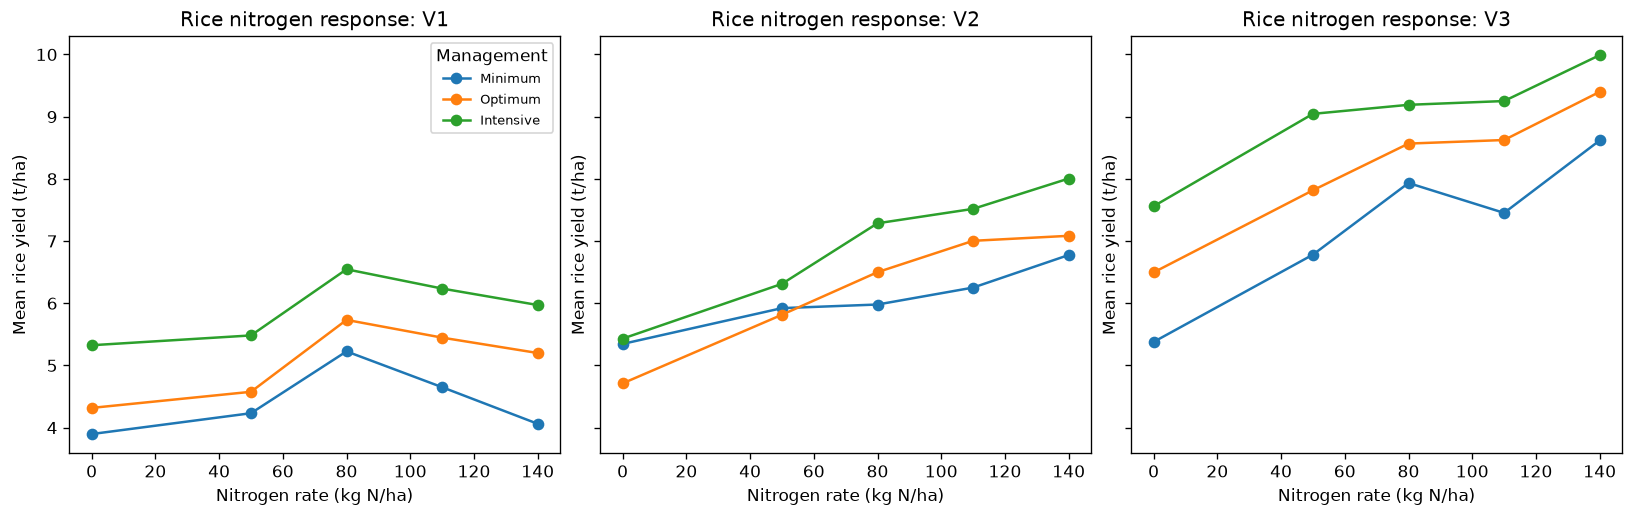

,df,F,p,denominator
source,,,,
Nitrogen,4.0,27.695334,9.733816e-05,Replicate×Nitrogen
Management,2.0,81.996489,2.302966e-10,Replicate×N×Management
Nitrogen×Management,8.0,0.526596,8.226476e-01,Replicate×N×Management
Variety,2.0,207.866712,1.055912e-27,Sub-sub-plot error
Nitrogen×Variety,8.0,3.567942,1.915655e-03,Sub-sub-plot error
Management×Variety,4.0,1.943212,1.148989e-01,Sub-sub-plot error
Nitrogen×Management×Variety,16.0,0.466564,9.537588e-01,Sub-sub-plot error


In [6]:
rice_means = (
    rice.groupby(["nrate", "management", "variety"], observed=True)["yield_t_ha"]
        .mean().reset_index()
)
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2), sharey=True, constrained_layout=True)
for ax, variety in zip(axes, V_LEVELS):
    sub = rice_means[rice_means["variety"] == variety]
    for management in M_LEVELS:
        line = sub[sub["management"] == management].sort_values("nrate")
        ax.plot(line["nrate"], line["yield_t_ha"], marker="o", label=management)
    ax.set(title=f"Rice nitrogen response: {variety}", xlabel="Nitrogen rate (kg N/ha)",
           ylabel="Mean rice yield (t/ha)")
axes[0].legend(title="Management", fontsize=8)
plt.show()

rice_tests = rice_stratified[rice_stratified["F"].notna()].set_index("source")[["df", "F", "p", "denominator"]]
rice_tests

The qualitative factorial analysis finds strong nitrogen, management, and variety effects. Nitrogen × variety is significant ($p\approx0.00192$): V1 bends downward after its mid-range response while V2 and V3 generally continue upward. Therefore, an average “nitrogen effect” is incomplete without variety. Nitrogen × management and the three-way interaction are not supported, so separate nitrogen curves for every management × variety cell would overcomplicate the evidence.

This is why factorial experiments are more informative than three disconnected one-factor studies: interaction asks whether the response to one factor changes with another.

### 5.2 Example 2: polynomial partition and lack of fit

The categorical block + nitrogen model estimates five treatment means and leaves 8 error df. Nested polynomial models use fewer treatment df. Comparing their residual sum of squares with the categorical model isolates lack of fit:

- linear model: 1 polynomial df + 3 lack-of-fit df;
- quadratic model: 2 polynomial df + 2 lack-of-fit df;
- full fourth-degree polynomial: all 4 treatment df, identical to categorical nitrogen.

Functional marginality requires the linear term whenever a quadratic is fitted.

In [7]:
beet_categorical = smf.ols("yield_t_ha ~ C(block) + C(N_kg_ha)", beet).fit()
beet_linear = smf.ols("yield_t_ha ~ C(block) + N_kg_ha", beet).fit()
beet_quadratic = smf.ols(
    'yield_t_ha ~ C(block, Treatment(reference="3")) + N_kg_ha + I(N_kg_ha**2)', beet
).fit()
beet_quartic = smf.ols(
    "yield_t_ha ~ C(block) + N_kg_ha + I(N_kg_ha**2) + I(N_kg_ha**3) + I(N_kg_ha**4)", beet
).fit()

full_poly_anova = anova_lm(beet_quartic, typ=1)
linear_lof = anova_lm(beet_linear, beet_categorical).iloc[1]
quadratic_lof = anova_lm(beet_quadratic, beet_categorical).iloc[1]

beet_partition = pd.DataFrame([
    ("Blocks", 2, full_poly_anova.loc["C(block)","sum_sq"], full_poly_anova.loc["C(block)","F"], full_poly_anova.loc["C(block)","PR(>F)"]),
    ("Linear N", 1, full_poly_anova.loc["N_kg_ha","sum_sq"], full_poly_anova.loc["N_kg_ha","F"], full_poly_anova.loc["N_kg_ha","PR(>F)"]),
    ("Quadratic N", 1, full_poly_anova.loc["I(N_kg_ha ** 2)","sum_sq"], full_poly_anova.loc["I(N_kg_ha ** 2)","F"], full_poly_anova.loc["I(N_kg_ha ** 2)","PR(>F)"]),
    ("Cubic N", 1, full_poly_anova.loc["I(N_kg_ha ** 3)","sum_sq"], full_poly_anova.loc["I(N_kg_ha ** 3)","F"], full_poly_anova.loc["I(N_kg_ha ** 3)","PR(>F)"]),
    ("Quartic N", 1, full_poly_anova.loc["I(N_kg_ha ** 4)","sum_sq"], full_poly_anova.loc["I(N_kg_ha ** 4)","F"], full_poly_anova.loc["I(N_kg_ha ** 4)","PR(>F)"]),
    ("Error", 8, full_poly_anova.loc["Residual","sum_sq"], np.nan, np.nan),
], columns=["source", "df", "SS", "F", "p"]).set_index("source")
display(beet_partition)

lof_table = pd.DataFrame([
    ("Linear", 3, linear_lof["ss_diff"], linear_lof["F"], linear_lof["Pr(>F)"]),
    ("Quadratic", 2, quadratic_lof["ss_diff"], quadratic_lof["F"], quadratic_lof["Pr(>F)"]),
], columns=["polynomial model", "lack_of_fit_df", "lack_of_fit_SS", "F", "p"]).set_index("polynomial model")
lof_table

,df,SS,F,p
source,,,,
Blocks,2,26.321333,3.711761,7.238120e-02
Linear N,1,651.468000,183.736392,8.429072e-07
Quadratic N,1,260.503810,73.471038,2.648616e-05
Cubic N,1,1.587000,0.447589,5.223163e-01
Quartic N,1,0.003857,0.001088,9.744966e-01
Error,8,28.365333,NaN,NaN


,lack_of_fit_df,lack_of_fit_SS,F,p
polynomial model,,,,
Linear,3,262.094667,24.639905,0.000215
Quadratic,2,1.590857,0.224338,0.803906


The linear model fails badly ($p\approx0.0002$), while the quadratic has negligible lack of fit ($p\approx0.804$). The cubic and quartic components jointly equal the quadratic lack-of-fit SS of about 1.59. Non-significant lack of fit means the replicated treatment means do not demand a more flexible curve at the available precision; it is not proof that a quadratic law holds beyond 0–140 kg N/ha.

In [8]:
param_order = beet_quadratic.params.index.tolist()
coef_table = pd.DataFrame({
    "estimate": beet_quadratic.params,
    "SE": beet_quadratic.bse,
    "CI_lower": beet_quadratic.conf_int()[0],
    "CI_upper": beet_quadratic.conf_int()[1],
})

# Article Table 6 also reports the curve averaged over blocks.
average_intercept_contrast = np.array([1, 1/3, 1/3, 0, 0])
avg_test = beet_quadratic.t_test(average_intercept_contrast)
average_intercept = float(np.asarray(avg_test.effect).item())
average_intercept_se = float(np.asarray(avg_test.sd).item())
average_intercept_ci = np.asarray(avg_test.conf_int()).ravel()
coef_table.loc["Average curve intercept"] = [average_intercept, average_intercept_se, *average_intercept_ci]

beta1 = beet_quadratic.params["N_kg_ha"]
beta2 = beet_quadratic.params["I(N_kg_ha ** 2)"]
N_opt = -beta1/(2*beta2)
yield_opt = average_intercept + beta1*N_opt + beta2*N_opt**2

display(coef_table)
print(f"Average fitted curve: yield = {average_intercept:.5f} + {beta1:.6f} N {beta2:+.8f} N²")
print(f"Stationary maximum within the observed range: N = {N_opt:.4f} kg/ha, predicted yield = {yield_opt:.4f} t/ha")

,estimate,SE,CI_lower,CI_upper
Intercept,11.519048,1.133065,8.994421,14.043674
"C(block, Treatment(reference=""3""))[T.1]",-2.380000,1.094645,-4.819021,0.059021
"C(block, Treatment(reference=""3""))[T.2]",-3.100000,1.094645,-5.539021,-0.660979
N_kg_ha,0.417769,0.031829,0.346849,0.488689
I(N_kg_ha ** 2),-0.002033,0.000218,-0.002519,-0.001547
Average curve intercept,9.692381,0.940437,7.596958,11.787804


Average fitted curve: yield = 9.69238 + 0.417769 N -0.00203304 N²
Stationary maximum within the observed range: N = 102.7447 kg/ha, predicted yield = 31.1541 t/ha


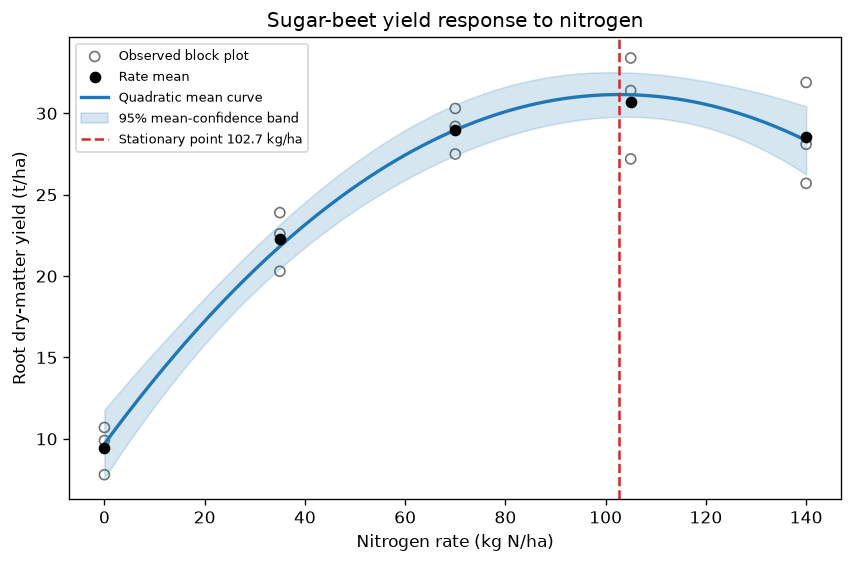

In [9]:
# Mean curve and its confidence band, averaged equally over the three blocks.
n_grid = np.linspace(0, 140, 241)
L = np.column_stack([np.ones_like(n_grid), np.full_like(n_grid,1/3), np.full_like(n_grid,1/3), n_grid, n_grid**2])
mean_curve = L @ beet_quadratic.params.to_numpy()
mean_se = np.sqrt(np.einsum("ij,jk,ik->i", L, beet_quadratic.cov_params().to_numpy(), L))
tcrit = stats.t.ppf(.975, beet_quadratic.df_resid)
rate_means = beet.groupby("N_kg_ha")["yield_t_ha"].mean()

fig, ax = plt.subplots(figsize=(8.3, 5.0))
ax.scatter(beet["N_kg_ha"], beet["yield_t_ha"], facecolor="none", edgecolor="0.45", label="Observed block plot")
ax.scatter(rate_means.index, rate_means.values, color="black", zorder=3, label="Rate mean")
ax.plot(n_grid, mean_curve, color="#1f77b4", lw=2, label="Quadratic mean curve")
ax.fill_between(n_grid, mean_curve-tcrit*mean_se, mean_curve+tcrit*mean_se, color="#1f77b4", alpha=.18,
                label="95% mean-confidence band")
ax.axvline(N_opt, color="#d62728", ls="--", label=f"Stationary point {N_opt:.1f} kg/ha")
ax.set(title="Sugar-beet yield response to nitrogen", xlabel="Nitrogen rate (kg N/ha)",
       ylabel="Root dry-matter yield (t/ha)")
ax.legend(fontsize=8)
plt.show()

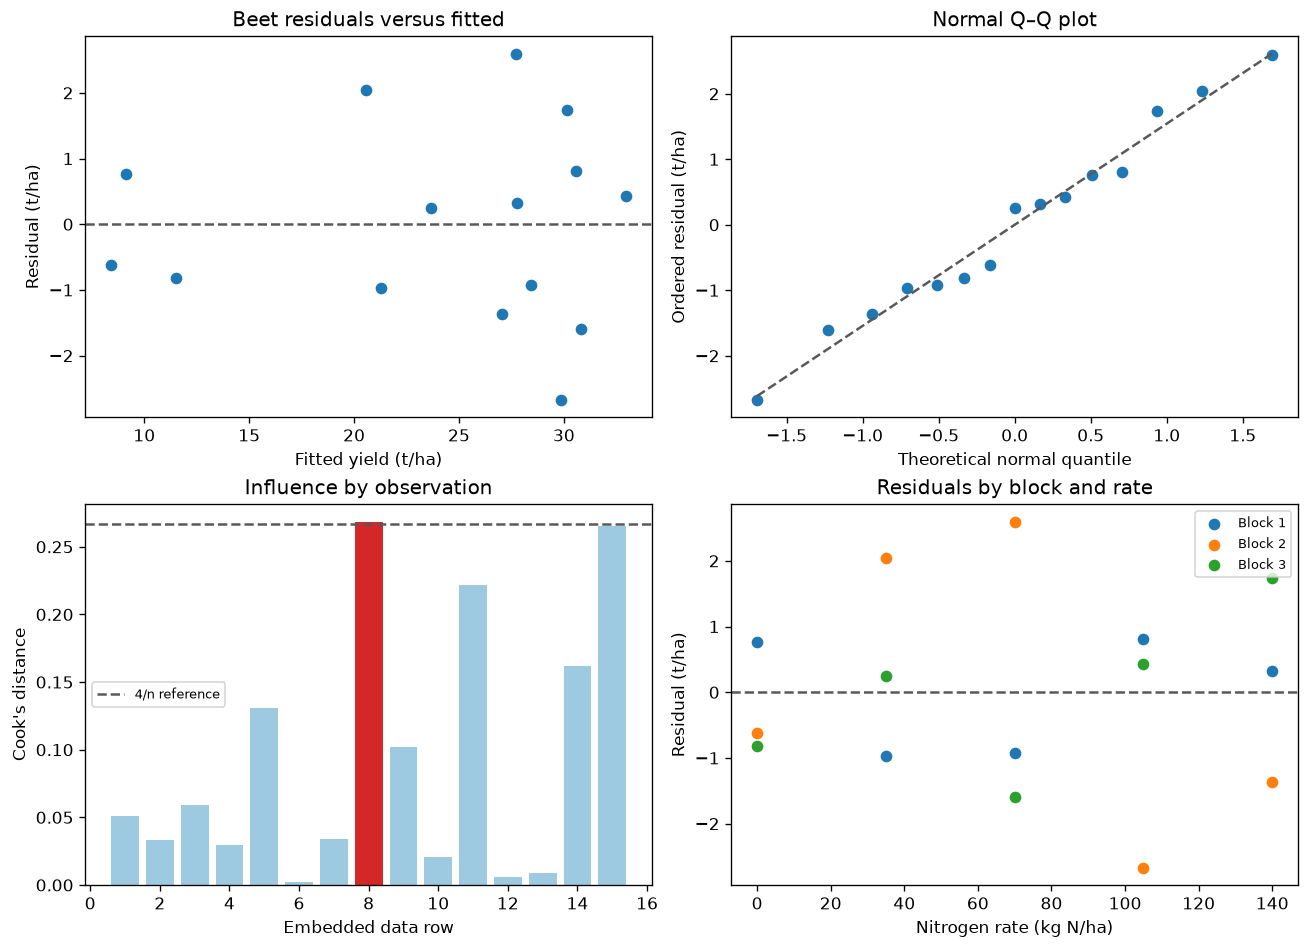

In [10]:
infl = beet_quadratic.get_influence()
resid = beet_quadratic.resid
fitted = beet_quadratic.fittedvalues
osm, osr = stats.probplot(resid, dist="norm", fit=False)
slope, intercept, *_ = stats.linregress(osm, osr)

fig, axes = plt.subplots(2, 2, figsize=(10.8, 7.8), constrained_layout=True)
axes[0,0].scatter(fitted, resid, color="#1f77b4"); axes[0,0].axhline(0, color="0.35", ls="--")
axes[0,0].set(title="Beet residuals versus fitted", xlabel="Fitted yield (t/ha)", ylabel="Residual (t/ha)")
axes[0,1].scatter(osm, osr, color="#1f77b4"); axes[0,1].plot(osm, intercept+slope*np.asarray(osm), "--", color="0.35")
axes[0,1].set(title="Normal Q–Q plot", xlabel="Theoretical normal quantile", ylabel="Ordered residual (t/ha)")
axes[1,0].bar(beet.index+1, infl.cooks_distance[0], color=np.where(infl.cooks_distance[0] > 4/len(beet), "#d62728", "#9ecae1"))
axes[1,0].axhline(4/len(beet), color="0.35", ls="--", label="4/n reference")
axes[1,0].set(title="Influence by observation", xlabel="Embedded data row", ylabel="Cook's distance"); axes[1,0].legend(fontsize=8)
for block, group in beet.assign(residual=resid).groupby("block"):
    axes[1,1].scatter(group["N_kg_ha"], group["residual"], label=f"Block {block}")
axes[1,1].axhline(0, color="0.35", ls="--")
axes[1,1].set(title="Residuals by block and rate", xlabel="Nitrogen rate (kg N/ha)", ylabel="Residual (t/ha)")
axes[1,1].legend(fontsize=8)
plt.show()

With only 15 observations, diagnostic power is modest. No point is removed: the Cook's-distance reference merely identifies observations worth checking against field records. The stationary point is interpolation because it lies between tested rates; extrapolating the quadratic beyond 140 kg/ha is not supported.

## 6. Validate against the paper

Published values below come from article Tables 1 and 4–6. Very small p-values are represented by stable F tests rather than forcing equality to a printed inequality.

In [11]:
validation_rows = [
    ("Rice nitrogen SS", 61.6, rice_stratified.set_index("source").loc["Nitrogen","SS"], .06, "Table 1 rounding"),
    ("Rice nitrogen F", 27.7, rice_tests.loc["Nitrogen","F"], .06, "main-plot denominator"),
    ("Rice management F", 82.0, rice_tests.loc["Management","F"], .06, "split-plot denominator"),
    ("Rice N×management F", .527, rice_tests.loc["Nitrogen×Management","F"], .002, "split-plot denominator"),
    ("Rice N×variety F", 3.57, rice_tests.loc["Nitrogen×Variety","F"], .01, "sub-sub-plot denominator"),
    ("Rice N×variety p", .00192, rice_tests.loc["Nitrogen×Variety","p"], .00002, "Table 1 rounding"),
    ("Beet blocks SS", 26.32, beet_partition.loc["Blocks","SS"], .01, "Table 4"),
    ("Beet linear N SS", 651.47, beet_partition.loc["Linear N","SS"], .01, "Tables 4–5"),
    ("Beet linear N F", 183.74, beet_partition.loc["Linear N","F"], .02, "Tables 4–5"),
    ("Beet linear-model LOF SS", 262.09, lof_table.loc["Linear","lack_of_fit_SS"], .01, "Table 4"),
    ("Beet linear-model LOF F", 24.64, lof_table.loc["Linear","F"], .02, "Table 4"),
    ("Beet quadratic N SS", 260.50, beet_partition.loc["Quadratic N","SS"], .01, "Table 5"),
    ("Beet quadratic-model LOF SS", 1.59, lof_table.loc["Quadratic","lack_of_fit_SS"], .01, "Table 5"),
    ("Beet quadratic-model LOF p", .8039, lof_table.loc["Quadratic","p"], .0001, "Table 5"),
    ("Average curve intercept", 9.69, average_intercept, .01, "Table 6/Figure 3"),
    ("Linear coefficient", .418, beta1, .001, "Table 6"),
    ("Quadratic coefficient", -.00203, beta2, .00001, "Table 6"),
]
validation = pd.DataFrame(validation_rows, columns=["target", "published", "reproduced", "tolerance", "explanation"])
validation["absolute_difference"] = (validation["reproduced"]-validation["published"]).abs()
validation["relative_difference"] = validation["absolute_difference"] / validation["published"].abs()
validation["within_tolerance"] = validation["absolute_difference"] <= validation["tolerance"]
validation[["target", "published", "reproduced", "absolute_difference", "relative_difference",
            "tolerance", "within_tolerance", "explanation"]]

,target,published,reproduced,absolute_difference,relative_difference,tolerance,within_tolerance,explanation
0,Rice nitrogen SS,61.60000,61.640822,0.040822,0.000663,0.06000,True,Table 1 rounding
1,Rice nitrogen F,27.70000,27.695334,0.004666,0.000168,0.06000,True,main-plot denominator
2,Rice management F,82.00000,81.996489,0.003511,0.000043,0.06000,True,split-plot denominator
3,Rice N×management F,0.52700,0.526596,0.000404,0.000767,0.00200,True,split-plot denominator
4,Rice N×variety F,3.57000,3.567942,0.002058,0.000576,0.01000,True,sub-sub-plot denominator
5,Rice N×variety p,0.00192,0.001916,0.000004,0.002263,0.00002,True,Table 1 rounding
6,Beet blocks SS,26.32000,26.321333,0.001333,0.000051,0.01000,True,Table 4
7,Beet linear N SS,651.47000,651.468000,0.002000,0.000003,0.01000,True,Tables 4–5
8,Beet linear N F,183.74000,183.736392,0.003608,0.000020,0.02000,True,Tables 4–5
9,Beet linear-model LOF SS,262.09000,262.094667,0.004667,0.000018,0.01000,True,Table 4


All selected targets agree within their stated printing tolerance. The key validation is structural as well as numeric: the rice F tests use the correct randomization stratum, and the beet lack-of-fit degrees of freedom complete the categorical treatment partition.

## 7. Go beyond the paper

### 7.1 What goes wrong with one residual denominator?

The raw OLS ANOVA software column uses the 60-df split-split-plot residual for every rice term. The comparison below contrasts those naive F values with the randomization-aware tests. This is a teaching demonstration; the correct column reproduces the article.

In [12]:
naive_terms = {
    "Nitrogen": "C(nitrogen)", "Management": "C(management)",
    "Nitrogen×Management": "C(nitrogen):C(management)",
    "Variety": "C(variety)", "Nitrogen×Variety": "C(nitrogen):C(variety)",
    "Management×Variety": "C(management):C(variety)",
    "Nitrogen×Management×Variety": "C(nitrogen):C(management):C(variety)",
}
wrong_error = pd.DataFrame({
    "correct_F": rice_tests.loc[list(naive_terms), "F"],
    "correct_p": rice_tests.loc[list(naive_terms), "p"],
    "naive_single_residual_F": [rice_raw_anova.loc[t,"F"] for t in naive_terms.values()],
    "naive_single_residual_p": [rice_raw_anova.loc[t,"PR(>F)"] for t in naive_terms.values()],
    "correct_denominator": rice_tests.loc[list(naive_terms), "denominator"],
})
wrong_error

,correct_F,correct_p,naive_single_residual_F,naive_single_residual_p,correct_denominator
source,,,,,
Nitrogen,27.695334,9.733816e-05,31.097710,5.005800e-14,Replicate×Nitrogen
Management,81.996489,2.302966e-10,43.322414,2.272663e-12,Replicate×N×Management
Nitrogen×Management,0.526596,8.226476e-01,0.278224,9.706861e-01,Replicate×N×Management
Variety,207.866712,1.055912e-27,207.866712,1.055912e-27,Sub-sub-plot error
Nitrogen×Variety,3.567942,1.915655e-03,3.567942,1.915655e-03,Sub-sub-plot error
Management×Variety,1.943212,1.148989e-01,1.943212,1.148989e-01,Sub-sub-plot error
Nitrogen×Management×Variety,0.466564,9.537588e-01,0.466564,9.537588e-01,Sub-sub-plot error


The naive analysis makes nitrogen look far more precise by giving it 60 denominator df instead of 8, while it makes management's F smaller because the wrong residual MS is larger than its actual split-plot error. A p-value can move in either direction when the design hierarchy is ignored.

### 7.2 A block-by-variety anomaly in the rice data

The package's extended analysis flags Replicate × Variety variation. In this balanced design, the interaction mean square can be compared with the deepest replicate × nitrogen × management × variety interaction. This is a data-quality diagnostic, not permission to delete V1 or a block.

In [13]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    saturated = smf.ols(
        "yield_t_ha ~ C(Replicate)*C(nitrogen)*C(management)*C(variety)", rice
    ).fit()
    saturated_aov = anova_lm(saturated, typ=1)

rv = saturated_aov.loc["C(Replicate):C(variety)"]
rnmv = saturated_aov.loc["C(Replicate):C(nitrogen):C(management):C(variety)"]
anomaly_F = (rv["sum_sq"]/rv["df"])/(rnmv["sum_sq"]/rnmv["df"])
anomaly_p = stats.f.sf(anomaly_F, rv["df"], rnmv["df"])
pd.Series({
    "Replicate×Variety_MS": rv["sum_sq"]/rv["df"],
    "Deepest_interaction_MS": rnmv["sum_sq"]/rnmv["df"],
    "F_ratio": anomaly_F,
    "p_value": anomaly_p,
    "article_rounded_F": 5.92,
    "article_rounded_p": .00110,
}).to_frame("value")

,value
Replicate×Variety_MS,1.538223
Deepest_interaction_MS,0.257293
F_ratio,5.978497
p_value,0.001039
article_rounded_F,5.920000
article_rounded_p,0.001100


The replicated variety response is not fully homogeneous across blocks. This explains why the paper cautions that apparently routine factorial data can hide anomalies. Statistical diagnosis should trigger a discussion with the experimenters and field records, not an automatic retrospective correction.

### 7.3 Scaling and uncertainty of the beet optimum

Raw $N$ and $N^2$ columns have very different magnitudes. Re-expressing $x=(N-70)/35$ leaves fitted values unchanged but improves conditioning. We also simulate coefficients from the fitted covariance matrix to show model-based uncertainty in the stationary point; this conditions on the quadratic being the correct model.

,parameterization,condition_number
0,"Raw N, N²",35926.590547
1,"Centred/scaled x, x²",9.350229


Model-based stationary-point 95% simulation interval: 95.77 to 112.68 kg N/ha
Fraction of coefficient draws concave: 1.000


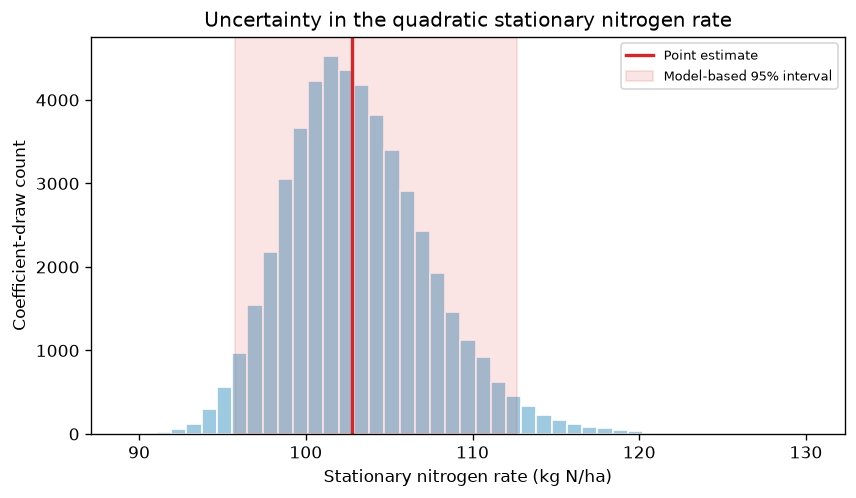

In [14]:
block_dummies = pd.get_dummies(beet["block"], drop_first=True, dtype=float).to_numpy()
N = beet["N_kg_ha"].to_numpy()
x = (N-70)/35
X_raw = np.column_stack([np.ones(len(beet)), block_dummies, N, N**2])
X_scaled = np.column_stack([np.ones(len(beet)), block_dummies, x, x**2])

draws = rng.multivariate_normal(beet_quadratic.params, beet_quadratic.cov_params(), size=50000)
draw_optima = -draws[:,3]/(2*draws[:,4])
concave = draws[:,4] < 0
valid_optima = draw_optima[concave]
opt_ci = np.quantile(valid_optima, [.025,.5,.975])

display(pd.DataFrame({
    "parameterization": ["Raw N, N²", "Centred/scaled x, x²"],
    "condition_number": [np.linalg.cond(X_raw), np.linalg.cond(X_scaled)],
}))
print(f"Model-based stationary-point 95% simulation interval: {opt_ci[0]:.2f} to {opt_ci[2]:.2f} kg N/ha")
print(f"Fraction of coefficient draws concave: {concave.mean():.3f}")

fig, ax = plt.subplots(figsize=(8.1,4.3))
ax.hist(valid_optima, bins=45, color="#9ecae1", edgecolor="white")
ax.axvline(N_opt, color="#d62728", lw=2, label="Point estimate")
ax.axvspan(opt_ci[0], opt_ci[2], color="#d62728", alpha=.12, label="Model-based 95% interval")
ax.set(title="Uncertainty in the quadratic stationary nitrogen rate",
       xlabel="Stationary nitrogen rate (kg N/ha)", ylabel="Coefficient-draw count")
ax.legend(fontsize=8)
plt.show()

Scaling cuts the design-matrix condition number by several orders of magnitude without changing predictions. The optimum is reasonably localized inside the tested range under the quadratic model, but this simulation does not include uncertainty about polynomial degree, agronomic cost, environmental response, or extrapolation to another field.

## 8. Practitioner conclusions

- **What factorial DoE made possible:** the rice design estimates all main effects and interactions in one experiment. It reveals that nitrogen response depends on variety—information separate one-factor trials could not recover coherently.
- **Why randomization structure matters:** nitrogen, management, and variety were applied to differently sized units. Each needs its own error stratum; “full factorial” does not imply one universal residual.
- **What polynomial modelling adds:** the beet design separates a smooth quantitative trend from treatment-specific lack of fit. A linear summary fails; a hierarchical quadratic is adequate at the experiment's precision.
- **What is supported versus fitted:** the rice N × variety interaction is supported by the correct sub-sub-plot test. The beet stationary point is fitted within the tested interval, but the quadratic's behaviour outside 0–140 kg N/ha is unsupported.
- **Replication lesson:** three blocks replicate treatments under field heterogeneity. They are not interchangeable with repeated laboratory readings from one plot.
- **Assumptions that matter:** additive block effects, appropriate stratum variances, independent experimental units, approximately normal/constant residuals, and a quadratic response over the observed beet rates.
- **Mistakes to avoid:** analysing a split-plot as a completely randomized experiment, treating quantitative levels as unrelated categories without checking a trend, dropping the linear term while retaining a quadratic, optimizing an inadequate polynomial, or reacting to an anomaly without consulting experiment records.

## 9. Reproducibility metadata

Checksums use stable CSV serialization of the two embedded source frames. The execution record includes the package-data revision, random seed, and live dependency versions.

In [15]:
def dataframe_sha256(frame):
    return hashlib.sha256(frame.to_csv(index=False, lineterminator="\n").encode("utf-8")).hexdigest()

metadata = pd.Series({
    "python": platform.python_version(),
    **{f"package_{k}": v for k, v in VERSIONS.items()},
    "random_seed": SEED,
    "execution_date_utc": pd.Timestamp.now(tz="UTC").date().isoformat(),
    "rice_sha256": dataframe_sha256(rice),
    "beet_sha256": dataframe_sha256(beet),
    "agriTutorial_revision": "519a40ddd75b3d1dd9f17f9914e50a5be2e7aed4",
    "article_doi": "10.1111/jac.12267",
    "reproduction_level": "B — analytical reproduction",
})
metadata.to_frame("value")

,value
python,3.13.2
package_pydoe,1.3.1.dev11+geca1a2598
package_numpy,2.3.4
package_pandas,3.0.0
package_scipy,1.16.2
package_statsmodels,0.14.6
package_matplotlib,3.11.1
random_seed,20180205
execution_date_utc,2026-08-01
rice_sha256,ec3d3d2d3637285083e7fd9660dca970c0c34817d4ff05...
